# Import các thư viện cần thiết

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.regularizers import l2
import seaborn as sns
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

# Tải lên dữ liệu

In [2]:
df = pd.read_csv('VIC.csv')

In [3]:
df.head()

,Ticker,Date/Time,Open,High,Low,Close,Volume,Open Interest
0,VIC,10/17/2018 9:39,98.5,98.5,98.5,98.5,390,0
1,VIC,10/17/2018 9:40,98.5,98.5,98.5,98.5,760,0
2,VIC,10/17/2018 9:41,98.6,98.6,98.6,98.6,2060,0
3,VIC,10/17/2018 9:42,98.6,98.6,98.6,98.6,5540,0
4,VIC,10/17/2018 9:43,98.6,98.7,98.6,98.7,760,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101266 entries, 0 to 101265
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Ticker         101266 non-null  object 
 1   Date/Time      101266 non-null  object 
 2   Open           101266 non-null  float64
 3   High           101266 non-null  float64
 4   Low            101266 non-null  float64
 5   Close          101266 non-null  float64
 6   Volume         101266 non-null  int64  
 7   Open Interest  101266 non-null  int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 6.2+ MB


In [5]:
df.describe()

,Open,High,Low,Close,Volume,Open Interest
count,101266.000000,101266.000000,101266.000000,101266.000000,1.012660e+05,101266.0
mean,105.376460,105.418519,105.334147,105.378791,3.182640e+03,0.0
std,11.543158,11.535584,11.552338,11.545054,1.469814e+04,0.0
min,68.000000,68.000000,68.000000,68.000000,1.000000e+01,0.0
25%,95.400000,95.400000,95.300000,95.400000,2.300000e+02,0.0
50%,105.300000,105.300000,105.200000,105.300000,1.020000e+03,0.0
75%,115.800000,115.900000,115.800000,115.800000,3.000000e+03,0.0
max,126.100000,126.500000,126.100000,126.500000,1.468390e+06,0.0


# Làm sạch dữ liệu

In [6]:
df = df.drop('Ticker', axis=1)
df = df.drop('Open Interest', axis=1)

In [7]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'], format='%m/%d/%Y %H:%M')

# Trực quan hóa dữ liệu

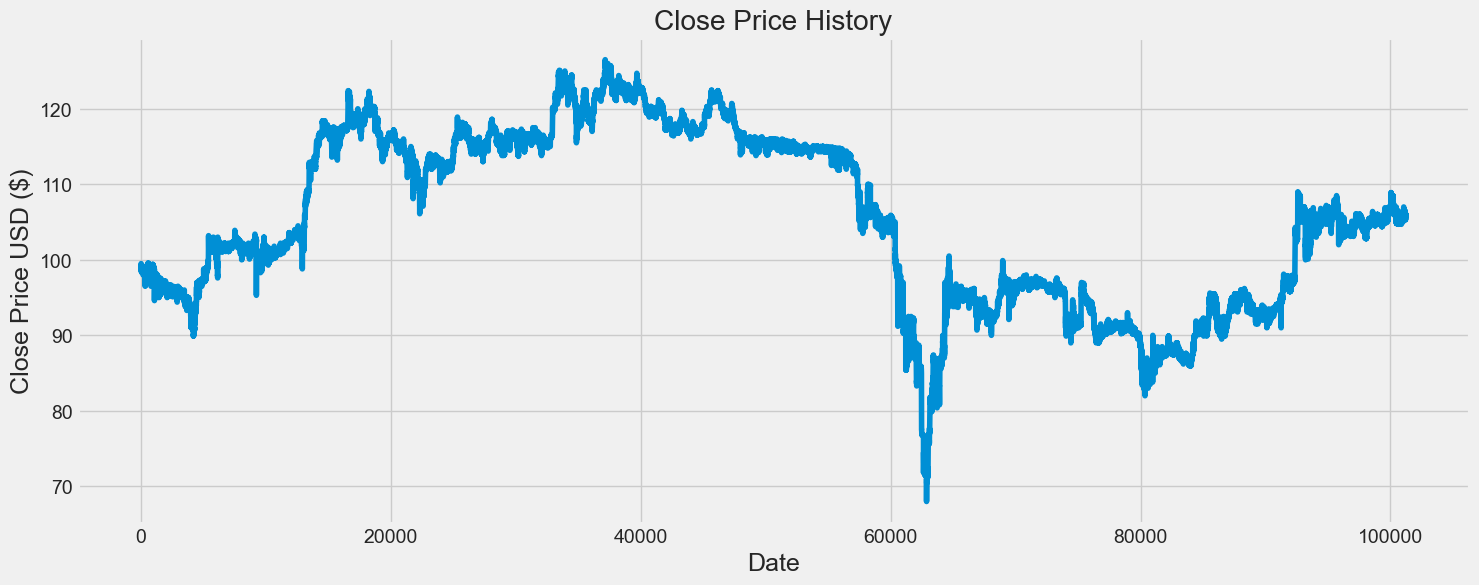

In [8]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

# Tiền xử lý dữ liệu

+ Lấy trung bình dữ liệu theo giờ để làm phẳng data và dễ dàng fill những data còn thiếu

In [9]:
df.set_index('Date/Time', inplace=True)

df = df.resample('H').mean()

In [10]:
df.describe()

,Open,High,Low,Close,Volume
count,2740.000000,2740.000000,2740.000000,2740.000000,2740.000000
mean,105.952109,105.993154,105.911421,105.955177,3298.088328
std,11.442857,11.435467,11.452005,11.444646,4105.352223
min,71.360000,71.522222,71.220000,71.415556,105.714286
25%,95.745290,95.779342,95.704914,95.737478,1267.875000
50%,105.720397,105.745000,105.684638,105.719044,2081.897478
75%,115.983598,115.997115,115.955018,115.987677,3826.388547
max,125.853659,125.880488,125.817073,125.853659,62819.259259


In [11]:
df.isnull().sum()

Open      16394
High      16394
Low       16394
Close     16394
Volume    16394
dtype: int64

+ Lấp vào những data còn thiếu để có thể sử dụng các model time-series

In [12]:
df.interpolate(method='linear', inplace=True)  
df.ffill(inplace=True) 

In [13]:
df.isnull().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

+ Chia data thành tập dự đoán và tập dữ liệu dùng để dự đoán để dễ dàng inverse scale

In [14]:
df_X = df.reset_index()[['Open', 'High', 'Low', 'Close', 'Volume']]


In [15]:
df_X

,Open,High,Low,Close,Volume
0,98.642105,98.689474,98.626316,98.668421,6384.736842
1,98.872000,98.906000,98.820000,98.848000,5230.200000
2,98.534615,98.580769,98.507692,98.553846,6928.461538
3,98.542308,98.579515,98.514716,98.550836,6030.426421
4,98.550000,98.578261,98.521739,98.547826,5132.391304
...,...,...,...,...,...
19129,106.210345,106.244828,106.144828,106.179310,1448.620690
19130,106.051852,106.085185,105.948148,105.996296,2810.740741
19131,105.886095,105.917169,105.810515,105.857470,2172.997489
19132,105.720339,105.749153,105.672881,105.718644,1535.254237


+ Data được dùng để dự đoán sẽ là data close sau time step sử dụng dữ liệu của các time-step trước đó

In [16]:
df_y = df.reset_index()['Close']

In [17]:
df_y

0         98.668421
1         98.848000
2         98.553846
3         98.550836
4         98.547826
            ...    
19129    106.179310
19130    105.996296
19131    105.857470
19132    105.718644
19133    105.862963
Name: Close, Length: 19134, dtype: float64

+ Mô hình được chọn là LSTM, vì nó có khả năng làm việc với dữ liệu trong theo thời gian rất tốt. Ngoài ra chúng ta còn có thể chọn ARIMA, tuy nhiên với dataset lớn và phức tạp như giá cổ phiếu, ARIMA sẽ không hoạt động tốt. Vì LSTM rất nhạy cảm với quy mô dữ liệu, chúng ta sẽ sử dụng MinMaxScaler.

+ Chúng ta phải chia thành 2 scaler ( một cho tập dữ liệu đầu vào và 1 tập dữ liệu đầu ra ) để có thể inverse scale mà không bị lỗi chiều dữ liệu

In [18]:
scaler1 = MinMaxScaler(feature_range=(0,4)) 
df_X = scaler1.fit_transform(np.array(df_X).reshape(-1, 5))

In [19]:
scaler2 = MinMaxScaler(feature_range=(0,1))   
df_y = scaler2.fit_transform(np.array(df_y).reshape(-1, 1))

In [20]:
df_X

array([[2.00258937, 1.9991257 , 2.00789634, 2.00248458, 0.40048908],
       [2.01946434, 2.01505898, 2.02208642, 2.01567968, 0.32685033],
       [1.99469928, 1.99112659, 1.9992055 , 1.99406586, 0.43516897],
       ...,
       [2.53432024, 2.5309819 , 2.53423949, 2.53072115, 0.13185561],
       [2.52215321, 2.51861828, 2.52415592, 2.52052049, 0.09117902],
       [2.53398156, 2.5289009 , 2.53753936, 2.53112475, 0.08446569]])

In [21]:
df_y

array([[0.50062115],
       [0.50391992],
       [0.49851646],
       ...,
       [0.63268029],
       [0.63013012],
       [0.63278119]])

In [22]:
data = np.concatenate([df_X, df_y], axis=1)

In [23]:
data

array([[2.00258937, 1.9991257 , 2.00789634, 2.00248458, 0.40048908,
        0.50062115],
       [2.01946434, 2.01505898, 2.02208642, 2.01567968, 0.32685033,
        0.50391992],
       [1.99469928, 1.99112659, 1.9992055 , 1.99406586, 0.43516897,
        0.49851646],
       ...,
       [2.53432024, 2.5309819 , 2.53423949, 2.53072115, 0.13185561,
        0.63268029],
       [2.52215321, 2.51861828, 2.52415592, 2.52052049, 0.09117902,
        0.63013012],
       [2.53398156, 2.5289009 , 2.53753936, 2.53112475, 0.08446569,
        0.63278119]])

+ Tạo dataset để train time-series model

In [24]:
training_size = int(len(data)*0.75)
test_size = len(data) - training_size
train_data_X = df_X[:training_size, :]
test_data_X = df_X[training_size:, :]
train_data_y = df_y[:training_size, :]
test_data_y = df_y[training_size:, :]

In [25]:
train_data_X.shape, test_data_X.shape

((14350, 5), (4784, 5))

In [26]:
def create_dataset(df_x, df_y, time_step=1):
    dataX, dataY = [], []
    for i in range(len(df_y) - time_step - 1):
        a = df_x[i:(i + time_step), :]
        dataX.append(a)
        dataY.append(df_y[i + time_step, -1])
    return np.array(dataX), np.array(dataY)

In [27]:
time_step = 100,
X_train, y_train = create_dataset(train_data_X, train_data_y, time_step[0])
X_test, y_test = create_dataset(test_data_X, test_data_y, time_step[0])

In [28]:
y_train = y_train.reshape(-1,1 )
y_test = y_test.reshape(-1,1 )

In [29]:
X_train 

array([[[2.00258937, 1.9991257 , 2.00789634, 2.00248458, 0.40048908],
        [2.01946434, 2.01505898, 2.02208642, 2.01567968, 0.32685033],
        [1.99469928, 1.99112659, 1.9992055 , 1.99406586, 0.43516897],
        ...,
        [1.98132075, 1.97916157, 1.98619573, 1.98019879, 0.58644486],
        [1.9821221 , 1.9800081 , 1.98697852, 1.9809822 , 0.56530723],
        [1.98292345, 1.98085462, 1.98776131, 1.98176561, 0.54416959]],

       [[2.01946434, 2.01505898, 2.02208642, 2.01567968, 0.32685033],
        [1.99469928, 1.99112659, 1.9992055 , 1.99406586, 0.43516897],
        [1.99526392, 1.9910343 , 1.99972007, 1.99384468, 0.37789043],
        ...,
        [1.9821221 , 1.9800081 , 1.98697852, 1.9809822 , 0.56530723],
        [1.98292345, 1.98085462, 1.98776131, 1.98176561, 0.54416959],
        [1.9837248 , 1.98170114, 1.9885441 , 1.98254903, 0.52303196]],

       [[1.99469928, 1.99112659, 1.9992055 , 1.99406586, 0.43516897],
        [1.99526392, 1.9910343 , 1.99972007, 1.99384468, 0.3

In [30]:
y_train

array([[0.49563726],
       [0.49583311],
       [0.49602896],
       ...,
       [0.44357812],
       [0.44361078],
       [0.44364343]])

In [31]:
X_test.shape, y_test.shape

((4683, 100, 5), (4683, 1))

In [32]:
print(X_train.shape), print(y_train.shape)
print(X_test.shape), print(y_test.shape)

(14249, 100, 5)
(14249, 1)
(4683, 100, 5)
(4683, 1)


(None, None)

# Tạo model Stacked LSTM

30 30 30 0.3 0.01 100 epochs

In [33]:
model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(40, return_sequences=True, input_shape=(time_step[0], 5)),
    tf.keras.layers.Dropout(0.3), 
    
    tf.keras.layers.LSTM(40, return_sequences=True),
    tf.keras.layers.Dropout(0.3), 
    
    tf.keras.layers.LSTM(40),
    tf.keras.layers.Dropout(0.3),  
    
    tf.keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')


c:\Users\phana\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [34]:
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

batch_size = 64
train_dataset = train_dataset.batch(batch_size).repeat()  
test_dataset = test_dataset.batch(batch_size)

+ Chọn số vòng lặp = 100 vì sau khi đánh giá model ta thấy từ sau vòng lặp 100 lỗi của mô hình sẽ tăng dần.

In [35]:
history = ( 
    model.fit(train_dataset, 
          validation_data=(X_test,y_test), 
          epochs=100, 
          steps_per_epoch=len(X_train) // batch_size, 
          verbose=1)
)

Epoch 1/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - loss: 0.0346 - val_loss: 0.0102
Epoch 2/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 22s 100ms/step - loss: 0.0092 - val_loss: 0.0135
Epoch 3/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - loss: 0.0111 - val_loss: 0.0146
Epoch 4/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - loss: 0.0101 - val_loss: 0.0153
Epoch 5/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - loss: 0.0099 - val_loss: 0.0152
Epoch 6/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - loss: 0.0091 - val_loss: 0.0122
Epoch 7/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - loss: 0.0093 - val_loss: 0.0093
Epoch 8/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 0.0087 - val_loss: 0.0058
Epoch 9/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 0.0079 - val_loss: 0.0045
Epoch 10/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - loss: 0.0073 - val_loss: 0.0028
Epoch 11/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - loss: 0.0066 - val_loss: 0.0046
Epoch 12/100
222/2

# Đánh giá model

+ Chúng ta cần xét loss của model qua mỗi epoch để có thể dừng train sớm, giảm thiểu tối đa loss

In [36]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.xlabel('Epoch')
  plt.ylabel('MSE')
  plt.legend()
  plt.grid(True)
  plt.show()

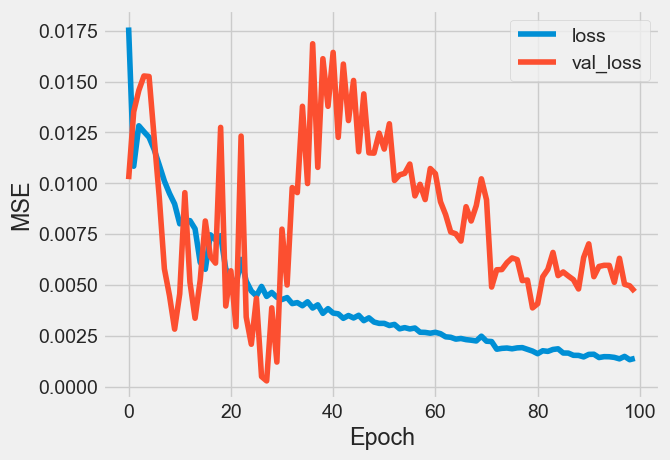

In [37]:
plot_loss(history)

+ Tiếp theo chúng ta cần đánh giá độ chính xác của dự đoán

In [38]:
predictions_scaled = model.predict(X_test)
predictions_scaled = predictions_scaled.reshape(-1,1)

predictions_train = model.predict(X_train) 
predictions_train = predictions_train.reshape(-1,1)

147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step
446/446 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step


In [39]:
predictions = scaler2.inverse_transform(predictions_scaled)
predictions_train = scaler2.inverse_transform(predictions_train)
y_test = scaler2.inverse_transform(y_test)
y_train = scaler2.inverse_transform(y_train)

In [40]:
column_names_pred = ['Close_predict']
df_predictions = pd.DataFrame(predictions, columns=column_names_pred)

df_test = pd.DataFrame(y_test)

In [41]:
df_predictions

,Close_predict
0,98.218353
1,98.032143
2,97.936806
3,98.060776
4,98.264587
...,...
4678,113.041718
4679,113.061630
4680,113.080132
4681,112.964218


In [42]:
df_test

,0
0,95.555172
1,95.660042
2,95.764912
3,95.789655
4,95.789003
...,...
4678,106.354762
4679,106.179310
4680,105.996296
4681,105.857470


In [43]:
concatenated = np.concatenate([df_predictions, df_test], axis=1)
column_names_concat = ['Close_predict', 'Close_test']
df_concatenated = pd.DataFrame(concatenated, columns = column_names_concat)

df_test.reset_index(drop=True, inplace=True)

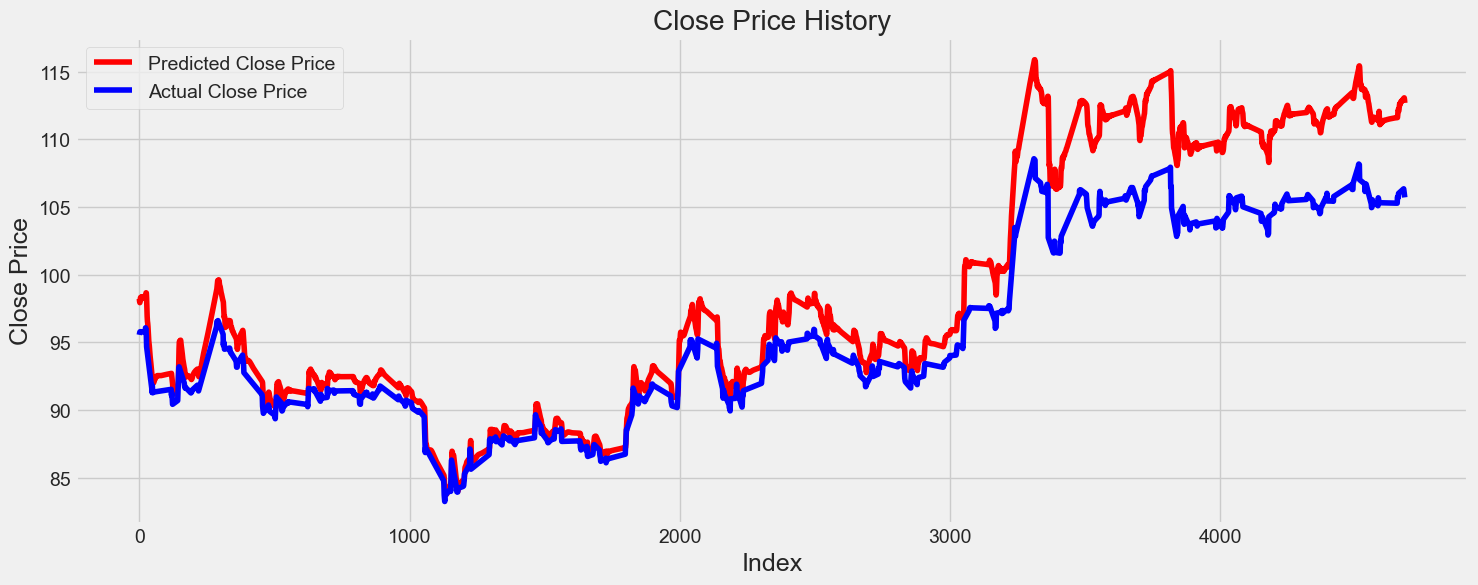

In [44]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df_predictions['Close_predict'], color='red', label='Predicted Close Price')
plt.plot(df_test, color='blue', label='Actual Close Price')
plt.legend()
plt.xlabel('Index', fontsize=18)
plt.ylabel('Close Price', fontsize=18)
plt.show()

+ Đánh giá độ hiệu quả của mô hình bằng các metrics

In [45]:
mae_train = mean_absolute_error(y_train, predictions_train)
rmse_train = mean_squared_error(y_train, predictions_train)
r2_train = r2_score(y_train, predictions_train)

print("Train Mean Absolute Error:", mae_train)
print("Train Mean Squared Error:", rmse_train)
print("Train R-squared:", r2_train)

Train Mean Absolute Error: 4.119139726179621
Train Mean Squared Error: 20.64004505563461
Train R-squared: 0.8117482079399028


In [46]:
mae_test = mean_absolute_error(y_test, predictions)
rmse_test = mean_squared_error(y_test, predictions)
r2_test = r2_score(y_test, predictions)

print("Test Mean Absolute Error:", mae_test)
print("Test Mean Squared Error:", rmse_test)
print("Test R-squared:", r2_test)

Test Mean Absolute Error: 2.8620799188771326
Test Mean Squared Error: 13.864416286315874
Test R-squared: 0.7111586283100564


# Dự đoán

In [47]:
len(test_data_X)

4784

In [48]:
demo_test = test_data_X

In [49]:
x_input = demo_test[-(time_step[0]):]

In [50]:
x_input

array([[2.5213943 , 2.51843535, 2.52394482, 2.51841578, 0.19886947],
       [2.51288622, 2.50976114, 2.51611889, 2.51096779, 0.1640145 ],
       [2.50437814, 2.50108693, 2.50829297, 2.5035198 , 0.12915953],
       [2.49461403, 2.4910266 , 2.49730981, 2.49165559, 1.39109292],
       [2.49457257, 2.49100672, 2.49722808, 2.49161659, 1.37281791],
       [2.49453111, 2.49098685, 2.49714635, 2.49157759, 1.35454289],
       [2.49448965, 2.49096697, 2.49706461, 2.49153859, 1.33626787],
       [2.49444819, 2.4909471 , 2.49698288, 2.49149959, 1.31799286],
       [2.49440673, 2.49092722, 2.49690115, 2.49146058, 1.29971784],
       [2.49436527, 2.49090735, 2.49681942, 2.49142158, 1.28144282],
       [2.4943238 , 2.49088747, 2.49673768, 2.49138258, 1.2631678 ],
       [2.49428234, 2.4908676 , 2.49665595, 2.49134358, 1.24489279],
       [2.49424088, 2.49084772, 2.49657422, 2.49130458, 1.22661777],
       [2.49419942, 2.49082785, 2.49649249, 2.49126558, 1.20834275],
       [2.49415796, 2.49080797, 2.

In [51]:
x_input = x_input.reshape(time_step[0], 5)

In [52]:
x_input.shape

(100, 5)

+ Tạo ra một dữ liệu test tạm thời

In [53]:
temp_input = list(x_input) 

In [54]:
temp_input_lists = [arr.tolist() for arr in temp_input]

In [55]:
temp_input 

[array([2.5213943 , 2.51843535, 2.52394482, 2.51841578, 0.19886947]),
 array([2.51288622, 2.50976114, 2.51611889, 2.51096779, 0.1640145 ]),
 array([2.50437814, 2.50108693, 2.50829297, 2.5035198 , 0.12915953]),
 array([2.49461403, 2.4910266 , 2.49730981, 2.49165559, 1.39109292]),
 array([2.49457257, 2.49100672, 2.49722808, 2.49161659, 1.37281791]),
 array([2.49453111, 2.49098685, 2.49714635, 2.49157759, 1.35454289]),
 array([2.49448965, 2.49096697, 2.49706461, 2.49153859, 1.33626787]),
 array([2.49444819, 2.4909471 , 2.49698288, 2.49149959, 1.31799286]),
 array([2.49440673, 2.49092722, 2.49690115, 2.49146058, 1.29971784]),
 array([2.49436527, 2.49090735, 2.49681942, 2.49142158, 1.28144282]),
 array([2.4943238 , 2.49088747, 2.49673768, 2.49138258, 1.2631678 ]),
 array([2.49428234, 2.4908676 , 2.49665595, 2.49134358, 1.24489279]),
 array([2.49424088, 2.49084772, 2.49657422, 2.49130458, 1.22661777]),
 array([2.49419942, 2.49082785, 2.49649249, 2.49126558, 1.20834275]),
 array([2.49415796, 

In [56]:
temp_input = np.array(temp_input)
temp_input.shape

(100, 5)

+ Đưa ra dự đoán cho 24 giờ tiếp theo

In [57]:
def predict_next_24_steps(model, initial_input, n_steps=24):
    predictions = []
    current_input = initial_input.copy() 

    for i in range(n_steps-1):
        if len(current_input.shape) == 2:
            current_input_reshaped = current_input.reshape(1, current_input.shape[0], current_input.shape[1])
        else:
            raise ValueError("current_input must be a 2D array with shape (time_steps, features)")

        next_step_prediction = model.predict(current_input_reshaped)[0, 0]  
        predictions.append(next_step_prediction)

        current_input = np.append(current_input[1:], [[next_step_prediction] + [0]*(current_input.shape[1]-1)], axis=0)

    return predictions

In [58]:
stocks = predict_next_24_steps(model, temp_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [59]:
stocks

[0.7526218,
 0.70330775,
 0.6563506,
 0.59175134,
 0.49786782,
 0.3950236,
 0.30299026,
 0.22140813,
 0.1463216,
 0.0798282,
 0.02428931,
 -0.019274354,
 -0.051245213,
 -0.073099434,
 -0.086826265,
 -0.09445137,
 -0.09772456,
 -0.09800345,
 -0.09627807,
 -0.09324592,
 -0.089375794,
 -0.08495855,
 -0.080160856]

In [60]:
print('Biến động cổ phiếu trong 24h tới:')
for i in stocks:
    a = scaler2.inverse_transform(i.reshape(-1, 1))
    print(a - df['Close'][-1])

Biến động cổ phiếu trong 24h tới:
[[6.5238953]]
[[3.8393326]]
[[1.283081]]
[[-2.2335815]]
[[-7.3444214]]
[[-12.943069]]
[[-17.953194]]
[[-22.394363]]
[[-26.481934]]
[[-30.101707]]
[[-33.125145]]
[[-35.496666]]
[[-37.2371]]
[[-38.426804]]
[[-39.174065]]
[[-39.589157]]
[[-39.76734]]
[[-39.78253]]
[[-39.6886]]
[[-39.523537]]
[[-39.31286]]
[[-39.072388]]
[[-38.81121]]
